In [8]:
import numpy as np
import matplotlib.pyplot as plt
import xsimlab as xs
import xarray as xr
import numba
%load_ext xsimlab.ipython

The xsimlab.ipython extension is already loaded. To reload it, use:
  %reload_ext xsimlab.ipython


# NoteBook2
We continue from NoteBook1 by using an implicit scheme and implementing the model into the xsimlab framework

We now use a finite difference approximation for the two derivatives in the SPL to obtain, using an implicit scheme (and separating the uplift term):

$$ h_i(t+\Delta t) = h_i(t) + \Delta t U $$

$$\frac{h_i(t+\Delta t)-h_i(t)}{\Delta t} =- K_fA^m\Bigl(\frac{h_i(t+\Delta t)-h_{i-1}(t+\Delta t)}{\Delta x}\Bigr)^n$$

After rearranging, we obtain an evolution equaiton for $h_i$ and $n=1$:

$$h_i(t+\Delta t) = \frac{h_i(t) + F_ih_{i-1}(t+\Delta t)}{1+F_i}$$

with

$$F_i=\frac{\Delta tK_fA_i^m}{\Delta x}$$


# $n=1$

Courant 5.083867916009749


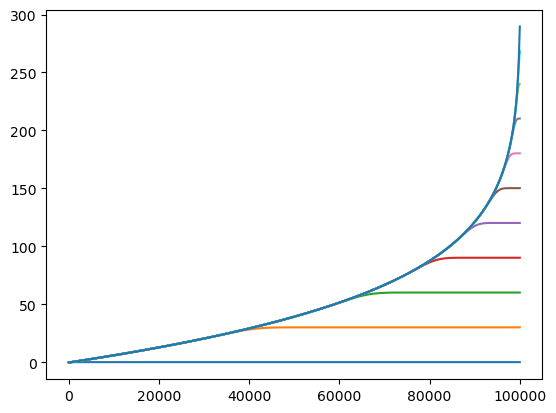

In [11]:
xl = 100e3
nx = 1001
dx = xl/(nx - 1)
x = np.linspace(0, xl, nx)
U = 1e-4
Kf = 1.e-5
m = 0.45
n = 1

tf = 3e6
nstep = 1001
dt = tf/(nstep - 1)

k = 0.25
p = 2
A = k*(xl - x)**p

print('Courant', Kf*A[0]**m*dt/dx)

h = np.zeros_like(x)

for step in range(nstep):
    h[1:] = h[1:] + dt*U
    F = Kf*A**m*dt/dx
    for i in range(1,nx):
        h[i] = (h[i] + F[i-1]*h[i-1])/(1 + F[i-1]) 
    if step%(nstep//10)==0: plt.plot(x,h)

# $n\ne 1$

In the case when $n\ne 1$, we need to find the root of a non-linear equation (in our case a polynomial expression of rank $n$):
$$h_i(t+\Delta t)= h_i(t) - F_i(h_i(t+\Delta t)-h_{i-1}(t+\Delta t))^n$$
For this, we use a Newton-Raphson algorithm to find the root of the following function $\mathcal{F}$, i.e., the value of $h_{i}(t+\Delta t)$ such that $\mathcal{F}(h_i(t + \Delta t))=0$:
$$\mathcal{F}(h_i(t+\Delta t))=h_i(t+\Delta t) - h_i(t) + F_i(h_i(t+\Delta t)-h_{i-1}(t+\Delta t))^n$$
The Newton-Raphson method is an iterative method that starts from a guessed value for the root (here we will use $h^0_i(t+\Delta t) = h_i(t)$) and improves the guess according to:
$$h^{k+1}_i(t+\Delta t) = h^k_i(t+\Delta t) - \frac{\mathcal{F}(h^k_i(t+\Delta t))}{\frac{\partial\mathcal{F}}{\partial h_i(t+\Delta t)}(h^k_i(t+\Delta t))}$$
which, in our case, leads to the following recurrence formula:
$$h^{k+1}_i(t+\Delta t) = h^k_i(t+\Delta t) - \frac{h^k_i(t+\Delta t) - h_i(t) + F_i(h^k_i(t+\Delta t)-h_{i-1}(t+\Delta t))^n}{1+F_in(h^k_i(t+\Delta t)-h_{i-1}(t+\Delta t))^{n-1}}$$

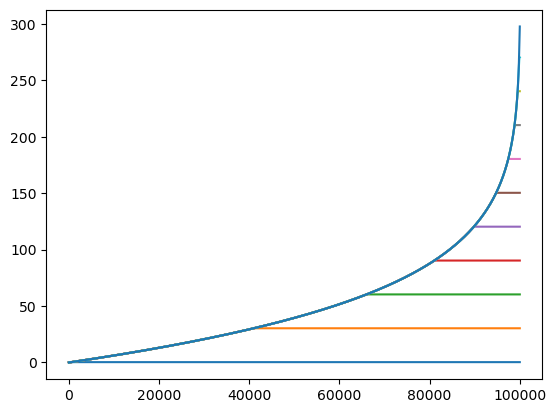

In [15]:
Kf = 1.e-6
m = 0.9
n = 2

h = np.zeros_like(x)

tol = 1e-3

for step in range(nstep):
    h[1:] = h[1:] + dt*U
    h0 = h.copy()
    F = Kf*A**m*dt/dx**n
    for i in range(1,nx):
        dh = 2*tol
        while abs(dh)>tol:
            dh = (h[i] - h0[i] + F[i-1]*(h[i] - h[i-1])**n)/(1 + F[i-1]*n*(h[i] - h[i-1])**(n-1))
            h[i] = h[i] - dh
    if step%(nstep//10)==0: plt.plot(x,h)

We can improve the efficiency of the algorithm by using `numba`

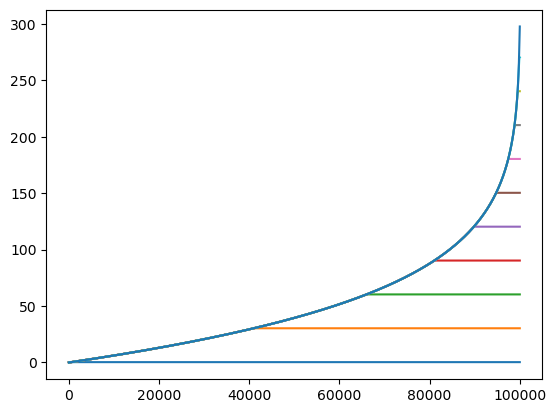

In [18]:
@numba.njit
def solve(h, h0, F, n):
    tol = 1e-3
    for i in range(1,len(h)):
        dh = 2*tol
        while abs(dh)>tol:
            dh = (h[i] - h0[i] + F[i-1]*(h[i] - h[i-1])**n)/(1 + F[i-1]*n*(h[i] - h[i-1])**(n-1))
            h[i] = h[i] - dh
    return h

Kf = 1.e-6
m = 0.9
n = 2

h = np.zeros_like(x)

for step in range(nstep):
    h[1:] = h[1:] + dt*U
    h0 = h.copy()
    F = Kf*A**m*dt/dx**n
    h = solve(h, h0, F, n)
    if step%(nstep//10)==0: plt.plot(x,h)

We now proceed to implement this into the `xarray` framework

In [2]:
@xs.process
class Geometry:
    '''
    Process to define the geometry of the 2D grid and compute the x- and y- coordinate arrays
    as well as the grid spacings in x- and y-directions
    '''
    
    shape = xs.variable(description="nb. of grid nodes in x", static=True)
    length = xs.variable(intent="in", description="total grid length in x", static=True)
    spacing = xs.variable(intent="out", description="grid spacing in x", static=True)
    
    x = xs.index(dims='x', description="grid x coordinate")
    
    def initialize(self):
        self.spacing = self.length / (self.shape - 1)
        self.x = np.linspace(0, self.length, self.shape)


In [3]:
@xs.process
class BoundaryCondition:
    '''
    Process to define base level nodes through a boolean mask array
    where True nodes are free to evolve, where False nodes are kept at their initial elevation
    '''
    mask = xs.variable(dims='x', description="base level mask", static=True)
    

In [4]:
@xs.process
class Topography:
    '''
    Process to update the topographic elevation by adding contributions from
    erosion processes (surface_down) and tectonic uplift (surface_up)
    '''
    elevation = xs.variable(dims='x', intent="inout", description="topography elevation")
    surface_down = xs.group('surf_down')
    surface_up = xs.group('surf_up')

    def finalize_step(self):
        surface_down_tot = sum((dtopo for dtopo in self.surface_down))
        surface_up_tot = sum((dtopo for dtopo in self.surface_up))
        self.elevation = self.elevation + surface_down_tot + surface_up_tot


In [5]:
@xs.process
class Drainage:
    '''
    Process to compute the drainage area following Hack's Law
    '''
    area = xs.variable(dims='x', intent="out", description="drainage area")
    x = xs.foreign(Geometry, "x")
    k = xs.variable(intent="in", description="Hack's law constant")
    p = xs.variable(intent="in", description="Hack's law exponent")
    
    def run_step(self):
        self.area = self.k * (self.x.max() - self.x)**self.p


In [6]:
@numba.jit(nopython=True)
def solve(h, dt, A, dx, Kf, m):
    F = dt*Kf*A**m/dx
    hn = h.copy()
    for i in range(1,len(h)):
        hn[i] = (h[i] + F[i-1]*hn[i-1])/(1 + F[i-1])
    return hn

@numba.jit(nopython=True)
def solveNL(h, dt, A, dx, Kf, m, n):
    F = dt*Kf*A**m/dx**n
    hn = h.copy()
    tol = 1e-3  
    for i in range(1,len(h)):
        dh = 2*tol
        while np.abs(dh) > tol:
            dh = (hn[i] - h[i] + F[i-1]*(hn[i] - hn[i-1])**n)/(1 + F[i-1]*n*(hn[i] - hn[i-1])**(n-1))
            hn[i] = hn[i] - dh
    return hn

@xs.process
class SPL:
    '''
    Process to compute the effect of SPL on the topography
    '''
    Kf = xs.variable(dims=[(),'x'],intent="in", description="diffusivity in (m^2/yr)")
    m = xs.variable(intent="in", description="exponent of the drainage area")
    surface_down = xs.variable(dims='x', intent="out", groups="surf_down", description="downward surface motion")
    shape = xs.foreign(Geometry, "shape")
    elevation = xs.foreign(Topography, "elevation")
    spacing = xs.foreign(Geometry, "spacing")
    mask = xs.foreign(BoundaryCondition, "mask")
    area = xs.foreign(Drainage, "area")
    
    @xs.runtime(args="step_delta")
    def run_step(self, dt):
        Kf = np.broadcast_to(self.Kf, self.shape)
        hn = solve(self.elevation, dt, self.area, self.spacing, Kf, self.m)
        dh = (hn - self.elevation)*self.mask
        self.surface_down = dh
        
@xs.process
class SPLn(SPL):
    '''
    Process to compute the effect of SPL assuming an arbitrary value for n
    '''
    n = xs.variable(intent="in", description="exponent of the topographic slope")
    
    @xs.runtime(args="step_delta")
    def run_step(self, dt):
        Kf = np.broadcast_to(self.Kf, self.shape)
        hn = solveNL(self.elevation, dt, self.area, self.spacing, Kf, self.m, self.n)
        dh = (hn - self.elevation)*self.mask
        self.surface_down = dh


In [7]:
@xs.process
class Uplift:
    '''
    Process to compute the increment in topography caused by tectonic uplift
    '''
    rate = xs.variable(dims=[(),'x'],intent="in", description="uplift rate in (m/yr)")
    surface_up = xs.variable(dims='x', intent="out", groups="surf_up", description="uplift")
    shape = xs.foreign(Geometry, "shape")
    mask = xs.foreign(BoundaryCondition, "mask")
    
    @xs.runtime(args="step_delta")
    def run_step(self, dt):
        uplift_rate = np.broadcast_to(self.rate, self.shape)
        self.surface_up = np.where(self.mask, uplift_rate*dt, 0)

In [8]:
model = xs.Model({'topography':Topography, 'spl':SPL,'geom':Geometry,'bc':BoundaryCondition, 'drainage': Drainage, 'uplift': Uplift})

In [9]:
xl = 100e3
nx = 1001
dx = xl/(nx - 1)
x = np.linspace(0, xl, nx)
U = 1e-4
Kf = 1.e-5
m = 0.45
n = 1

mask = np.ones(nx, dtype=bool)
mask[0] = False

tf = 3e6
nstep = 1001
tstep = np.linspace(0, tf, nstep)
time = np.linspace(0, tf, 11)

k = 0.25
p = 2


In [21]:
# %create_setup model
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={'tstep': tstep,
            'time': time},
    master_clock = 'tstep',
    input_vars={
        'topography__elevation': np.zeros(nx),
        'spl__Kf': Kf,
        'spl__m': m,
        'uplift__rate': U,
        'geom__shape': nx,
        'geom__length': xl,
        'bc__mask': mask,
        'drainage__k': k,
        'drainage__p': p,
    },
    output_vars={'topography__elevation':'time',
                 'drainage__area':'time'}
)


In [22]:
with model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run()

             0% | initialize 

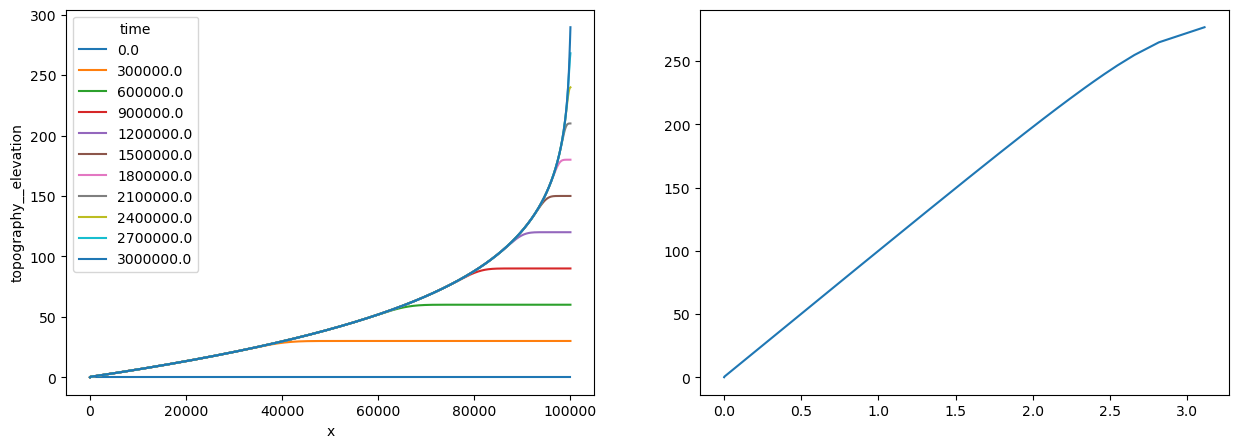

In [48]:
fig, ax = plt.subplots(ncols=2, figsize=(15,5))
ds_out.topography__elevation.plot.line(x='x', ax=ax[0])
ax[1].plot((ds_out.uplift__rate/ds_out.spl__Kf*ds_out.drainage__area.isel(time=-1)**(-ds_out.spl__m)).cumsum(dim='x'),ds_out.topography__elevation.isel(time=-1));
 

In [24]:
with model.update_processes({'spl':SPLn}), xs.monitoring.ProgressBar():
    ds_out_n = ds_in.xsimlab.update_vars(input_vars={'spl__n':2, 'spl__m':0.9, 'spl__Kf':1e-6}).xsimlab.run()
    

             0% | initialize 

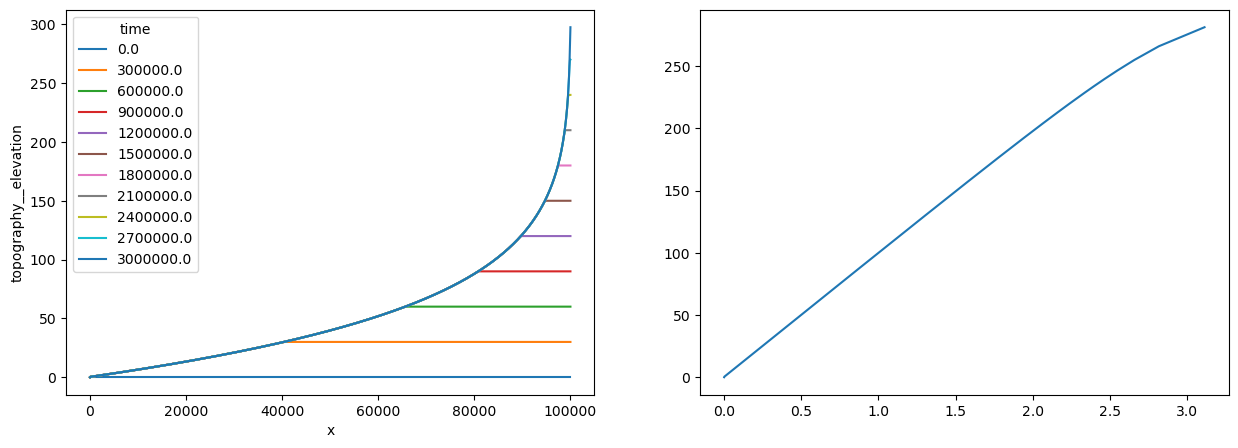

In [49]:
fig, ax = plt.subplots(ncols=2, figsize=(15,5))
ds_out_n.topography__elevation.plot.line(x='x', ax=ax[0])
ax[1].plot((ds_out_n.uplift__rate/ds_out_n.spl__Kf)**(1/ds_out_n.spl__n)*(ds_out_n.drainage__area.isel(time=-1)**(-ds_out_n.spl__m/ds_out_n.spl__n)).cumsum(dim='x'),ds_out_n.topography__elevation.isel(time=-1));


In [41]:
urate = xr.where(ds_out.x<ds_in.geom__length*0.85, U/2, U*2)

with model.update_processes({'spl':SPLn}), xs.monitoring.ProgressBar():
    ds_out_nU = ds_in.xsimlab.update_vars(input_vars={'spl__n':2, 'spl__m':0.9, 'spl__Kf':1e-6, 'uplift__rate':urate}).xsimlab.run()

             0% | initialize 

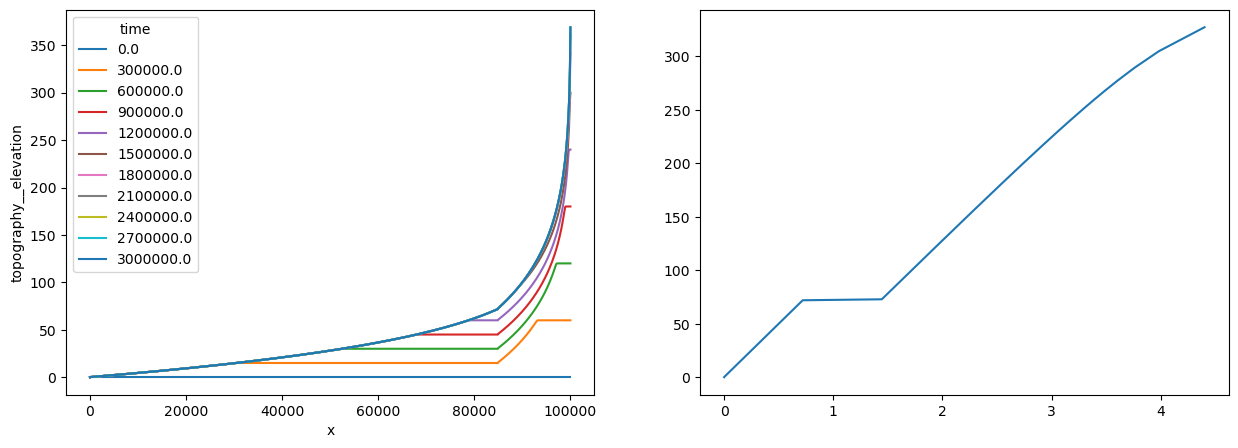

In [51]:
fig, ax = plt.subplots(ncols=2, figsize=(15,5))
ds_out_nU.topography__elevation.plot.line(x='x', ax=ax[0])
ax[1].plot((ds_out_nU.uplift__rate/ds_out_nU.spl__Kf)**(1/ds_out_nU.spl__n)*(ds_out_nU.drainage__area.isel(time=-1)**(-ds_out_nU.spl__m/ds_out_nU.spl__n)).cumsum(dim='x'),ds_out_nU.topography__elevation.isel(time=-1));